In [132]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Set LaTeX style
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Liberation Serif'],
    'mathtext.fontset': 'stix',
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'legend.fontsize': 10,
    'legend.title_fontsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.linewidth': 0.8,
    'grid.linewidth': 0.4,
    'grid.alpha': 0.2,
    'lines.linewidth': 1.5,
})


In [133]:
# Load data
td_production = pd.read_csv("output/operations/production_details.csv")
td_losses = pd.read_csv("output/operations/TD_losses.csv")
td_weight = pd.read_csv("data/inputs/preprocessed_weights.csv")[['gcm','ssp','decade','td','weight']].rename(columns={'ssp':'SSP','decade':'Decade','td':'Day'})
td_weight = td_weight[['SSP','Decade','Day','weight']].groupby(['SSP','Decade','Day']).mean().reset_index()

mask = td_weight['Decade'] == '2020s'
past_weight = td_weight[mask][['Decade','Day','weight']].groupby(['Decade','Day']).mean().reset_index()
past_weight['SSP'] = 'past'
future_weight = td_weight[~mask][['SSP','Decade','Day','weight']].groupby(['SSP','Decade','Day']).mean().reset_index()

td_weight = pd.concat([past_weight,future_weight])
print(pd.concat([past_weight,future_weight]))
td_weight

    Decade  Day      weight     SSP
0    2020s    0  258.166667    past
1    2020s    1  430.875000    past
2    2020s    2  268.416667    past
3    2020s    3  212.833333    past
4    2020s    4  229.875000    past
..     ...  ...         ...     ...
507  2100s   11   12.000000  ssp585
508  2100s   12    3.500000  ssp585
509  2100s   13   32.200000  ssp585
510  2100s   14   16.200000  ssp585
511  2100s   15   25.200000  ssp585

[528 rows x 4 columns]


,Decade,Day,weight,SSP
0,2020s,0,258.166667,past
1,2020s,1,430.875000,past
2,2020s,2,268.416667,past
3,2020s,3,212.833333,past
4,2020s,4,229.875000,past
...,...,...,...,...
507,2100s,11,12.000000,ssp585
508,2100s,12,3.500000,ssp585
509,2100s,13,32.200000,ssp585
510,2100s,14,16.200000,ssp585


In [137]:
SSP = 'ssp126'
Decade = '2050s'

Text(0, 0.5, 'Energy balance MWh/day')

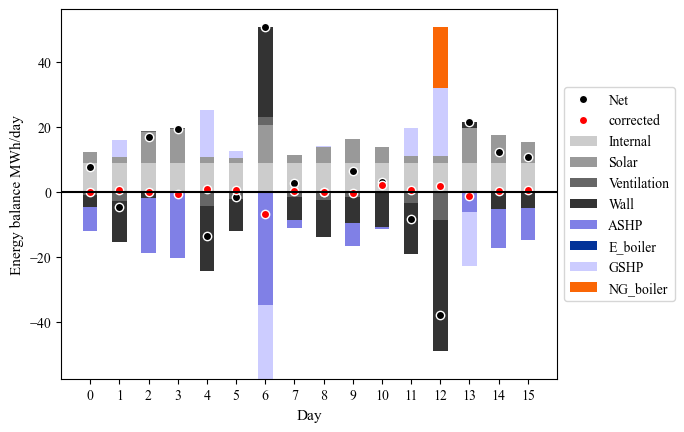

In [138]:
# color losses
loss_types = td_losses['Loss_type'].unique()
n_types = len(loss_types)
grey_shades = np.linspace(0.2, 0.8, n_types)  # Range from dark to light grey
loss_type_colors = {loss_type: str(shade) for loss_type, shade in zip(loss_types, grey_shades)}

# color production
prod_type = ['GSHP','NG_boiler','ASHP','E_boiler']
tech_colors = {'NG_boiler':(0.98, 0.4, 0.02),
               'GSHP':    (0.8,0.8,1.0),
               'ASHP':    (0.5,0.5,0.9),
               'E_boiler':(0.01,0.2,0.6)}

combined_colors = {**loss_type_colors, **tech_colors}

mask = (td_losses['SSP'] == SSP) * (td_losses['Decade'] == Decade)
pivot_data_loss = td_losses[mask].pivot_table(index='Day', columns='Loss_type', values='Value', aggfunc='sum')

mask2 = (td_production['SSP'] == SSP) * (td_production['Decade'] == Decade)
pivot_data_prod = td_production[mask2].pivot_table(index='Day', columns='Technology', values='Value', aggfunc='sum')

res = pd.merge(pivot_data_loss,pivot_data_prod, left_index = True, right_index = True) / 1000

res.plot(kind='bar', stacked=True, color=[combined_colors[col] for col in res.columns])
(pivot_data_loss / 1000).sum(axis=1).plot(marker='o', linestyle='', color='k', markeredgecolor = 'white', label = 'Net')
res.sum(axis=1).plot(marker='o', linestyle='', color='red', markeredgecolor = 'white', label = 'corrected')

plt.hlines(xmin=td_losses['Day'].min()-1, xmax=td_losses['Day'].max()+1, y=0, color='k')
plt.xlim(td_losses['Day'].min()-1, td_losses['Day'].max()+1)

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.ylabel('Energy balance MWh/day')

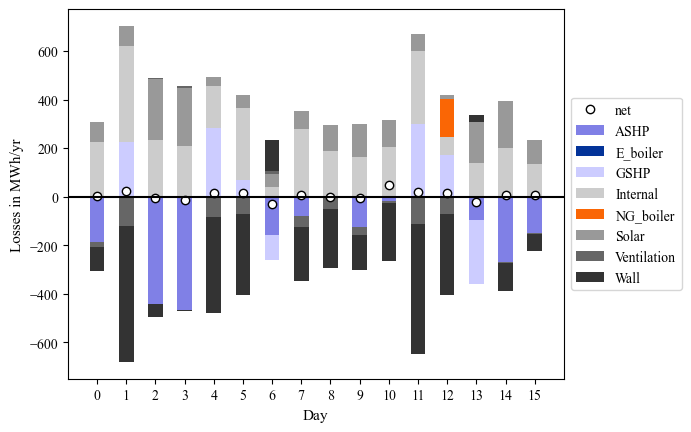

In [139]:
df = pd.concat([td_losses.rename(columns={'Loss_type':'Origin'}),td_production.rename(columns={'Technology':'Origin'})], axis = 0)
processed_weight = td_weight
joined_df = df.merge(processed_weight, on=['SSP', 'Decade', 'Day'])
joined_df['Value'] = joined_df['Value'] * joined_df['weight'] / 10 / 1e3 # / 10 years / 1000 kWh -> MWh


mask = (joined_df['SSP'] == SSP) * (joined_df['Decade'] == Decade)

pivot_data = joined_df[mask].pivot_table(index='Day', columns='Origin', values='Value', aggfunc='sum')
pivot_data.plot(kind='bar', stacked=True, color=[combined_colors[col] for col in pivot_data.columns])
pivot_data.sum(axis=1).plot(marker='o', linestyle='', color='white', markeredgecolor = 'black', label = 'net')
plt.hlines(xmin=joined_df['Day'].min()-1, xmax=joined_df['Day'].max()+1, y=0, color='k')
plt.xlim(joined_df['Day'].min()-1, joined_df['Day'].max()+1)
plt.ylabel('Losses in MWh/yr')
# plt.legend()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

['ssp126' 'ssp245' 'ssp370' 'ssp585']


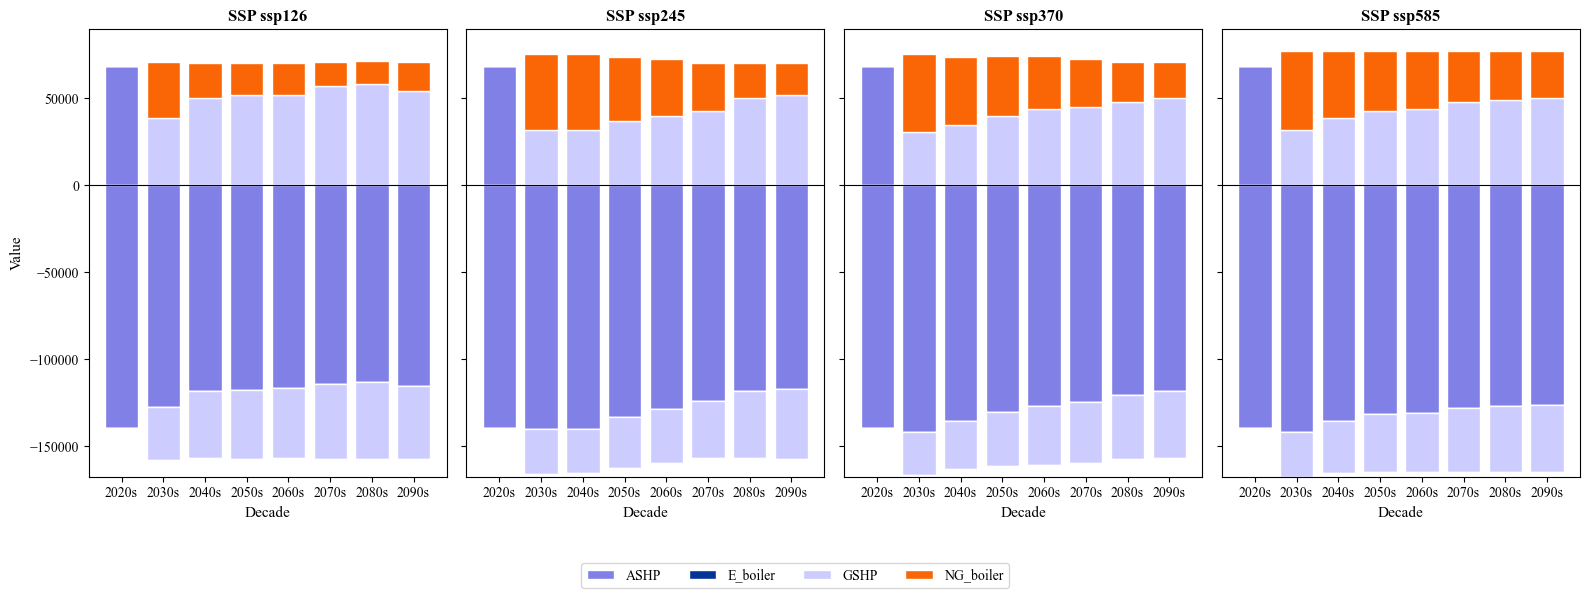

In [153]:
df = td_production.copy()
# Prepare data: separate positive and negative values
df['Value_Pos'] = df['Value'].where(df['Value'] >= 0, 0)
df['Value_Neg'] = df['Value'].where(df['Value'] < 0, 0)

# Group by SSP, Decade, Technology and sum positive/negative values
grouped = df.groupby(['SSP', 'Decade', 'Technology']).agg({
    'Value_Pos': 'sum',
    'Value_Neg': 'sum'
}).reset_index()

# Get unique SSPs and Decades
ssps = (np.delete(df['SSP'].unique(),df['SSP'].unique()=='past'))
print(ssps)
decades = sorted(df['Decade'].unique())
techs = sorted(df['Technology'].unique())

# Create subplots
fig, axes = plt.subplots(1, len(ssps), figsize=(4*len(ssps), 6), sharey=True)
if len(ssps) == 1:
    axes = [axes]

# Create bar plots for each SSP
for idx, ssp in enumerate(ssps):
    ax = axes[idx]
    ssp_data = grouped[(grouped['SSP'] == ssp) + (grouped['SSP'] == 'past')]
    
    # Prepare data for stacking
    pos_stacks = []
    neg_stacks = []
    
    for tech in techs:
        tech_data = ssp_data[ssp_data['Technology'] == tech]
        # Align with decades
        tech_dict = dict(zip(tech_data['Decade'], tech_data['Value_Pos']))
        pos_stacks.append([tech_dict.get(dec, 0) for dec in decades])
        
        tech_dict = dict(zip(tech_data['Decade'], tech_data['Value_Neg']))
        neg_stacks.append([tech_dict.get(dec, 0) for dec in decades])
    
    # Plot positive stacks (upward)
    bottom_pos = np.zeros(len(decades))
    for i, tech in enumerate(techs):
        ax.bar(decades, pos_stacks[i], bottom=bottom_pos, 
               color=tech_colors[tech], label=tech, edgecolor='white')
        bottom_pos += pos_stacks[i]
    
    # Plot negative stacks (downward)
    bottom_neg = np.zeros(len(decades))
    for i, tech in enumerate(techs):
        ax.bar(decades, neg_stacks[i], bottom=bottom_neg, 
               color=tech_colors[tech], edgecolor='white')
        bottom_neg += neg_stacks[i]
    
    ax.set_title(f'SSP {ssp}')
    ax.set_xlabel('Decade')
    if idx == 0:
        ax.set_ylabel('Value')
    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.set_xticks(decades)

# Add legend
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(techs), bbox_to_anchor=(0.5, -0.05))

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()